# Tieback Screening with NeqSim

This notebook supports the TPG4230 field-development workflow: define a satellite discovery, define host options, run tieback hydraulics and flow-assurance screening, and rank host alternatives by feasibility, CAPEX and NPV.


In [1]:
from pathlib import Path
import json
import math
import sys
import subprocess

for package in ['matplotlib', 'pandas']:
    try:
        __import__(package)
    except ModuleNotFoundError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package])

import matplotlib.pyplot as plt
import pandas as pd

try:
    NOTEBOOK_DIR = Path(__vsc_ipynb_file__).resolve().parent
except NameError:
    NOTEBOOK_DIR = Path.cwd().resolve()

CHAPTER_DIR = NOTEBOOK_DIR.parent
FIGURES_DIR = CHAPTER_DIR / 'figures'
FIGURES_DIR.mkdir(exist_ok=True)
BOOK_DIR = CHAPTER_DIR
for candidate in [CHAPTER_DIR] + list(CHAPTER_DIR.parents):
    if (candidate / 'book.yaml').exists():
        BOOK_DIR = candidate
        break
PROJECT_ROOT = BOOK_DIR
for candidate in [BOOK_DIR] + list(BOOK_DIR.parents):
    if (candidate / 'pom.xml').exists() and (candidate / 'devtools' / 'neqsim_dev_setup.py').exists():
        PROJECT_ROOT = candidate
        break
sys.path.insert(0, str(PROJECT_ROOT / 'devtools'))
from neqsim_dev_setup import neqsim_init
ns = neqsim_init(project_root=PROJECT_ROOT, recompile=False, verbose=False)
JClass = ns.JClass
ArrayList = JClass('java.util.ArrayList')
FieldConcept = JClass('neqsim.process.fielddevelopment.concept.FieldConcept')
ReservoirInput = JClass('neqsim.process.fielddevelopment.concept.ReservoirInput')
WellsInput = JClass('neqsim.process.fielddevelopment.concept.WellsInput')
InfrastructureInput = JClass('neqsim.process.fielddevelopment.concept.InfrastructureInput')
TiebackAnalyzer = JClass('neqsim.process.fielddevelopment.tieback.TiebackAnalyzer')
HostFacility = JClass('neqsim.process.fielddevelopment.tieback.HostFacility')

def update_results(section, data):
    path = BOOK_DIR / 'results.json'
    if path.exists():
        results = json.loads(path.read_text(encoding='utf-8'))
    else:
        results = {}
    results[section] = data
    path.write_text(json.dumps(results, indent=2), encoding='utf-8')
    return path

print(f'Project root: {PROJECT_ROOT}')
print(f'Book directory: {BOOK_DIR}')


Project root: C:\Users\ESOL\Documents\GitHub\neqsim
Book directory: C:\Users\ESOL\Documents\GitHub\neqsim\neqsim-paperlab\books\tpg4230_field_development_and_operations_2026


## Discovery and Host Definition

The discovery is a rich-gas satellite with two producers. Three host facilities are screened with different distance, water-depth, pressure and spare-capacity assumptions.


In [2]:
satellite = FieldConcept.builder('Ultima Thule Satellite') \
    .reservoir(ReservoirInput.richGas().resourceEstimate(12.0, 'GSm3').recoveryFactor(0.70).co2Percent(1.5).h2sPercent(0.0).build()) \
    .wells(WellsInput.builder().producerCount(2).ratePerWell(1.2e6, 'Sm3/d').tubeheadPressure(125.0).build()) \
    .infrastructure(InfrastructureInput.subseaTieback().tiebackLength(30.0).waterDepth(350.0).exportPressure(160.0).build()) \
    .build()

hosts = ArrayList()
hosts.add(HostFacility.builder('Host A platform').location(61.50, 2.30).waterDepth(120.0).spareGasCapacity(5.0).spareOilCapacity(18000.0).waterCapacity(12000.0).liquidCapacity(25000.0).minTieInPressure(80.0).build())
hosts.add(HostFacility.builder('Host B hub').location(61.80, 2.10).waterDepth(330.0).spareGasCapacity(8.0).spareOilCapacity(35000.0).waterCapacity(30000.0).liquidCapacity(50000.0).minTieInPressure(70.0).build())
hosts.add(HostFacility.builder('Host C constrained').location(62.00, 2.50).waterDepth(90.0).spareGasCapacity(1.6).spareOilCapacity(10000.0).waterCapacity(8000.0).liquidCapacity(14000.0).minTieInPressure(95.0).build())

analyzer = TiebackAnalyzer()
analyzer.setGasPriceUsdPerSm3(0.24)
analyzer.setDiscountRate(0.08)
report = analyzer.analyze(satellite, hosts, 61.60, 2.40)
best = report.getBestFeasibleOption()
print(report.getSummary())
print('Best feasible host:', best.getHostName() if best is not None else 'none')


TIEBACK ANALYSIS REPORT: Ultima Thule Satellite
Discovery location: 61.6000°N, 2.4000°E
Options evaluated: 3
Feasible options: 2
Profitable options: 2

----------------------------------------------------------------------
Host                 Distance      CAPEX        NPV      IRR     Status
                         (km)     (MUSD)     (MUSD)      (%)           
----------------------------------------------------------------------
Host A platform          30.0      389.0      167.5     18.2     VIABLE
Host B hub               30.0      404.8      161.5     17.5     VIABLE
Host C constrained       30.0        0.0        0.0      0.0       FAIL
----------------------------------------------------------------------

BEST OPTION: Host A platform
  Distance: 30.0 km
  CAPEX: 389.0 MUSD
  NPV: 167.5 MUSD
  IRR: 18.2%
  Payback: 5.0 years
  Flow Assurance: MARGINAL

Best feasible host: Host A platform


In [3]:
rows = []
for option in report.getOptions():
    rows.append({
        'host': str(option.getHostName()),
        'feasible': bool(option.isFeasible()),
        'hydraulic_feasible': bool(option.isHydraulicFeasible()),
        'distance_km': float(option.getDistanceKm()),
        'diameter_in': float(option.getPipelineDiameterInches()),
        'arrival_pressure_bara': float(option.getArrivalPressureBara()),
        'arrival_temperature_C': float(option.getArrivalTemperatureC()),
        'hydrate_margin_C': float(option.getHydrateMarginC()),
        'hydrate_formation_C': float(option.getHydrateFormationTemperatureC()),
        'cooldown_risk_pct': float(option.getShutdownCooldownRiskScore()) * 100.0,
        'total_capex_MUSD': float(option.getTotalCapexMusd()),
        'npv_MUSD': float(option.getNpvMusd()),
        'flow_regime': str(option.getFlowRegime()),
        'host_capacity': str(option.getHostCapacitySummary())
    })
df = pd.DataFrame(rows).sort_values('npv_MUSD', ascending=False)
df


,host,feasible,hydraulic_feasible,distance_km,diameter_in,arrival_pressure_bara,arrival_temperature_C,hydrate_margin_C,hydrate_formation_C,cooldown_risk_pct,total_capex_MUSD,npv_MUSD,flow_regime,host_capacity
0,Host A platform,True,True,30.0,10.0,110.548546,10.516119,-5.538735,16.054855,55.0,389.00,167.546127,ANNULAR,Capacity: Gas 2.40/5.00 MSm3/d OK; Oil 0/18000...
1,Host B hub,True,True,30.0,10.0,110.548546,10.516119,-5.538735,16.054855,55.0,404.75,161.537964,ANNULAR,Capacity: Gas 2.40/8.00 MSm3/d OK; Oil 0/35000...
2,Host C constrained,False,True,30.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.00,0.000000,None,Capacity: Gas 2.40/1.60 MSm3/d LIMIT; Oil 0/10...


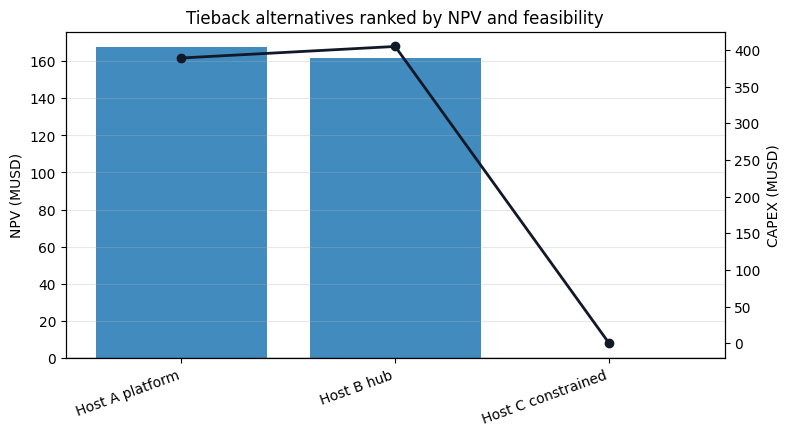

In [4]:
colors = ['#1f77b4' if feasible else '#b91c1c' for feasible in df['feasible']]
fig, ax1 = plt.subplots(figsize=(8.5, 4.8))
ax1.bar(df['host'], df['npv_MUSD'], color=colors, alpha=0.85, label='NPV')
ax1.axhline(0.0, color='#334155', linewidth=1.0)
ax1.set_ylabel('NPV (MUSD)')
ax1.set_title('Tieback alternatives ranked by NPV and feasibility')
ax1.grid(True, axis='y', alpha=0.3)
ax2 = ax1.twinx()
ax2.plot(df['host'], df['total_capex_MUSD'], color='#111827', marker='o', linewidth=2.0, label='CAPEX')
ax2.set_ylabel('CAPEX (MUSD)')
fig.autofmt_xdate(rotation=20)
fig.savefig(FIGURES_DIR / 'ch24_10_tieback_npv_capex.png', dpi=150, bbox_inches='tight')
plt.show()


**Discussion.** *Observation.* The feasible hosts separate from constrained hosts when NPV and CAPEX are plotted together. *Mechanism.* Distance, host pressure, spare capacity and route hydraulics all feed into modifications, pressure arrival and the economic result. *Implication.* A short tieback is not automatically best if host capacity or tie-in pressure is limiting. *Recommendation.* Screen at least two hosts before committing to a base-case tieback route.


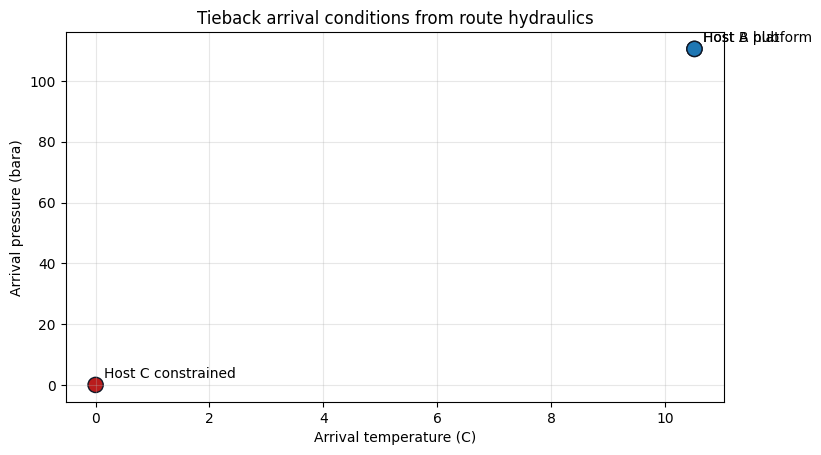

In [5]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.scatter(df['arrival_temperature_C'], df['arrival_pressure_bara'], s=120, c=colors, edgecolor='#111827')
for _, row in df.iterrows():
    ax.annotate(row['host'], (row['arrival_temperature_C'], row['arrival_pressure_bara']), xytext=(6, 5), textcoords='offset points')
ax.set_xlabel('Arrival temperature (C)')
ax.set_ylabel('Arrival pressure (bara)')
ax.set_title('Tieback arrival conditions from route hydraulics')
ax.grid(True, alpha=0.3)
fig.savefig(FIGURES_DIR / 'ch24_10_arrival_conditions.png', dpi=150, bbox_inches='tight')
plt.show()


**Discussion.** *Observation.* The screened options arrive at different pressure and temperature combinations. *Mechanism.* Flowline length, water depth and heat transfer change frictional and thermal losses before the stream reaches the host. *Implication.* Arrival conditions determine whether host tie-in pressure and flow-assurance margins are acceptable. *Recommendation.* Treat arrival pressure and temperature as design variables, not just reporting outputs.


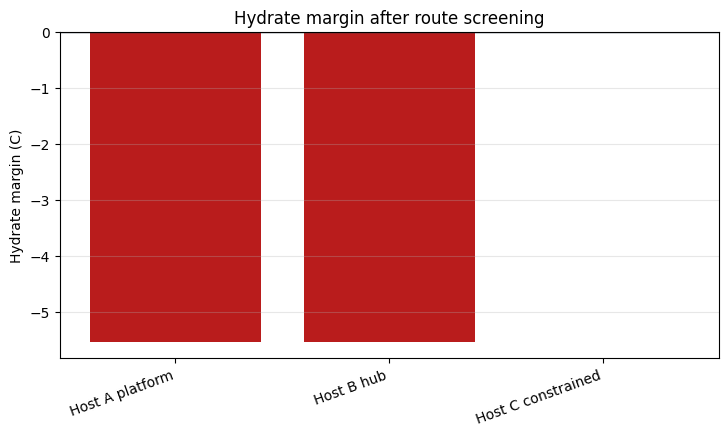

In [6]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.bar(df['host'], df['hydrate_margin_C'], color=['#15803d' if v > 0 else '#b91c1c' for v in df['hydrate_margin_C']])
ax.axhline(0.0, color='#334155', linewidth=1.0)
ax.set_ylabel('Hydrate margin (C)')
ax.set_title('Hydrate margin after route screening')
ax.grid(True, axis='y', alpha=0.3)
fig.autofmt_xdate(rotation=20)
fig.savefig(FIGURES_DIR / 'ch24_10_hydrate_margin.png', dpi=150, bbox_inches='tight')
plt.show()


**Discussion.** *Observation.* Hydrate margin is the clearest flow-assurance go/no-go indicator in this screening case. *Mechanism.* Low seabed temperature and pressure retention can move operating conditions toward the hydrate formation boundary. *Implication.* A profitable route may still require insulation, heating or inhibitor injection. *Recommendation.* Carry the hydrate margin and shutdown cooldown risk into concept-selection risk scoring.


In [7]:
best_row = df.iloc[0].to_dict()
section = {
    'best_host': best_row['host'],
    'best_host_npv_musd': best_row['npv_MUSD'],
    'best_host_capex_musd': best_row['total_capex_MUSD'],
    'arrival_pressure_bara': best_row['arrival_pressure_bara'],
    'arrival_temperature_c': best_row['arrival_temperature_C'],
    'hydrate_margin_c': best_row['hydrate_margin_C'],
    'options': df.to_dict(orient='records'),
    'figures': [
        'figures/ch24_10_tieback_npv_capex.png',
        'figures/ch24_10_arrival_conditions.png',
        'figures/ch24_10_hydrate_margin.png'
    ]
}
results_path = update_results('tieback_screening', section)
print(f'Updated {results_path}')
section


Updated C:\Users\ESOL\Documents\GitHub\neqsim\neqsim-paperlab\books\tpg4230_field_development_and_operations_2026\results.json


{'best_host': 'Host A platform',
 'best_host_npv_musd': 167.54612660792012,
 'best_host_capex_musd': 389.0,
 'arrival_pressure_bara': 110.54854625109066,
 'arrival_temperature_c': 10.516119148233713,
 'hydrate_margin_c': -5.5387354768753525,
 'options': [{'host': 'Host A platform',
   'feasible': True,
   'hydraulic_feasible': True,
   'distance_km': 30.0,
   'diameter_in': 10.0,
   'arrival_pressure_bara': 110.54854625109066,
   'arrival_temperature_C': 10.516119148233713,
   'hydrate_margin_C': -5.5387354768753525,
   'hydrate_formation_C': 16.054854625109066,
   'cooldown_risk_pct': 55.00000000000001,
   'total_capex_MUSD': 389.0,
   'npv_MUSD': 167.54612660792012,
   'flow_regime': 'ANNULAR',
   'host_capacity': 'Capacity: Gas 2.40/5.00 MSm3/d OK; Oil 0/18000 bbl/d OK; Water 0/12000 m3/d OK; Liquid 0/25000 m3/d OK; No process model attached'},
  {'host': 'Host B hub',
   'feasible': True,
   'hydraulic_feasible': True,
   'distance_km': 30.0,
   'diameter_in': 10.0,
   'arrival_pre